# Random Forest (6/6) — Hyperparameters and Tuning

### The idea in one sentence
> A random forest works well out of the box, but a few knobs (`n_estimators`, `max_features`, `max_depth`,
> `max_samples`, …) control the **strength vs diversity** of its trees. A search with cross-validation finds good
> settings for **your** data.

### In this notebook
1. The heart disease data, and a fair comparison: random forest vs other models
2. The main hyperparameters, explained
3. What `max_depth`, `max_features` and `max_samples` do (validation curves)
4. **GridSearchCV:** try every combination
5. **RandomizedSearchCV:** try a random subset of combinations
6. Final comparison on the test set

> 📖 Theory: [`theory.md`](theory.md) §6 and §13 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
import time
from sklearn.model_selection import (train_test_split, cross_val_score, StratifiedKFold,
                                     GridSearchCV, RandomizedSearchCV, validation_curve)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

## 1. Data and a first comparison

**Heart disease data (UCI):** 303 patients, 13 features, `target` = 1 if the patient has heart disease.

In [2]:
df = pd.read_csv('heart.csv')
X = df.drop(columns='target')
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("train:", X_train.shape, "| test:", X_test.shape)
df.head()

train: (242, 13) | test: (61, 13)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


We compare four models. Two of them (SVC and logistic regression) **need scaled features**, so we put a
`StandardScaler` in front of them with a pipeline. Trees and forests do not need scaling.

With only 242 training rows, one test split of 61 patients is noisy (one patient = 1.6 points). So we report both
**5-fold cross-validation** on the training set (more reliable) and the test accuracy.

> ✍️ **Core code: learn this.** Fair comparison: same folds for every model.

In [3]:
models = {
    'Random forest':       RandomForestClassifier(random_state=42),
    'Gradient boosting':   GradientBoostingClassifier(random_state=42),
    'SVC (rbf)':           make_pipeline(StandardScaler(), SVC()),
    'Logistic regression': make_pipeline(StandardScaler(), LogisticRegression()),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, n_jobs=-1)
    test = model.fit(X_train, y_train).score(X_test, y_test)
    rows.append({'model': name, 'CV mean': scores.mean(), 'CV std': scores.std(), 'test accuracy': test})

compare = pd.DataFrame(rows).set_index('model').round(3)
compare

,CV mean,CV std,test accuracy
model,,,
Random forest,0.827,0.041,0.836
Gradient boosting,0.823,0.040,0.770
SVC (rbf),0.814,0.031,0.869
Logistic regression,0.806,0.062,0.852


**What the numbers say:**
- In **cross-validation** the default random forest is the best of the four (0.827), but all four are within about
  2 points (0.806–0.827), and the spread across folds (CV std 0.03–0.06) is larger than the gaps between models.
- On the **test split** the order is different: SVC 0.869, logistic regression 0.852, random forest 0.836,
  gradient boosting 0.770. A difference of 0.033 is just 2 patients.
- Honest conclusion: on this small dataset **no model is clearly best**. The forest is a strong, safe default
  with no scaling and no tuning.

> 🔧 **Fixed from the original version:** SVC and logistic regression were trained on unscaled features. Without
> scaling, SVC drops to 0.705 test accuracy and `LogisticRegression` warns that it did not converge. They now use a
> `StandardScaler` pipeline, so the comparison is fair.

## 2. The main hyperparameters

| Parameter | Default | What it controls | Typical values to try |
|---|---|---|---|
| `n_estimators` | 100 | number of trees. More = more stable, slower. **Never causes overfitting.** | 100–500 |
| `max_features` | `'sqrt'` | features tried **at each split**. Lower = more diverse but weaker trees | `'sqrt'`, `'log2'`, 0.2–1.0 |
| `max_depth` | None | how deep each tree can grow. Lower = simpler trees | 3–20, None |
| `min_samples_split` | 2 | rows needed to split a node | 2, 5, 10 |
| `min_samples_leaf` | 1 | rows needed in each leaf. Higher = smoother | 1, 2, 5 |
| `max_samples` | None (= all *n*) | size of each bootstrap sample (fraction or count). Lower = more diverse trees, faster | 0.5–1.0 |
| `bootstrap` | True | sample rows with replacement? If False every tree sees all rows (and no OOB score) | True |
| `n_jobs` | None | `-1` = use all CPU cores | -1 |

The usual order of importance: `max_features` and the depth/leaf-size settings matter most; `n_estimators` just
needs to be "large enough".

## 3. Seeing the effect of single hyperparameters

`validation_curve` changes **one** hyperparameter and records the training and cross-validation accuracy.

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

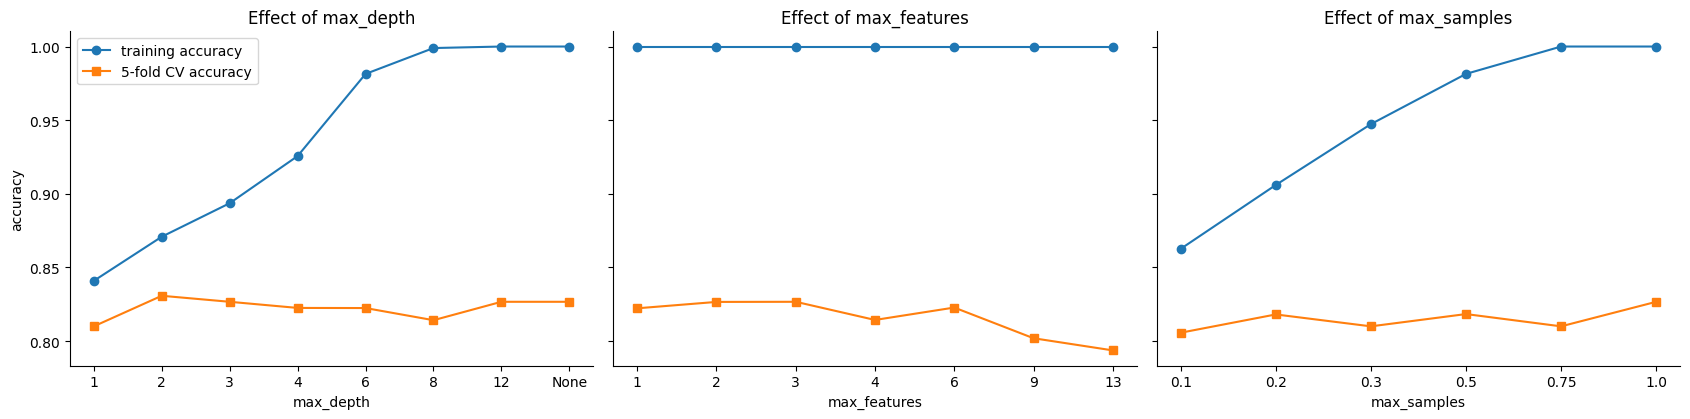

CV accuracy by max_depth: {'1': 0.81, '2': 0.831, '3': 0.827, '4': 0.823, '6': 0.822, '8': 0.814, '12': 0.827, 'None': 0.827}
CV accuracy by max_features: {'1': 0.822, '2': 0.827, '3': 0.827, '4': 0.814, '6': 0.823, '9': 0.802, '13': 0.794}
CV accuracy by max_samples: {'0.1': 0.806, '0.2': 0.818, '0.3': 0.81, '0.5': 0.818, '0.75': 0.81, '1.0': 0.827}


In [4]:
settings = [('max_depth', [1, 2, 3, 4, 6, 8, 12, None]),
            ('max_features', [1, 2, 3, 4, 6, 9, 13]),
            ('max_samples', [0.1, 0.2, 0.3, 0.5, 0.75, 1.0])]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3), sharey=True)
curves = {}
for ax, (param, values) in zip(axes, settings):
    tr, va = validation_curve(RandomForestClassifier(n_estimators=100, random_state=42), X_train, y_train,
                              param_name=param, param_range=values, cv=cv, n_jobs=-1)
    labels = [str(v) for v in values]
    ax.plot(labels, tr.mean(axis=1), 'o-', label='training accuracy')
    ax.plot(labels, va.mean(axis=1), 's-', label='5-fold CV accuracy')
    ax.set_xlabel(param)
    ax.set_title(f'Effect of {param}')
    curves[param] = pd.Series(va.mean(axis=1), index=labels).round(3)
axes[0].set_ylabel('accuracy')
axes[0].legend()
plt.tight_layout()
plt.show()
for p, s in curves.items():
    print(f"CV accuracy by {p}:", s.to_dict())

**Reading the curves** (blue = training, orange = cross-validation):
- **`max_depth`:** deeper trees fit the training data perfectly (1.0 from depth 8). The CV accuracy hardly moves
  (0.81–0.83): averaging many deep trees already controls overfitting. Depth 1 (stumps) is the weakest (0.810).
- **`max_features`:** few features per split (1–3; the default `'sqrt'` gives √13 ≈ 3.6 → 3) gives the best CV accuracy
  (≈ 0.82–0.83). Using **all 13** features at every split (= plain bagging) is the worst here (0.794): the trees
  become too similar.
- **`max_samples`:** smaller bootstrap samples make each tree see less data (lower training accuracy). CV accuracy
  changes only a little (0.806–0.827), with the full-size sample best here.
- All CV differences are small (a few points), so on 242 rows they are partly noise.

## 4. GridSearchCV: try every combination

`GridSearchCV` trains and cross-validates **every** combination in the grid. Here: 3 × 3 × 3 × 3 = **81**
combinations × 5 folds = **405** forests.

> ✍️ **Core code: learn this.** A grid search with 5-fold CV on all CPU cores.

In [5]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': [0.2, 0.6, 1.0],      # fraction of the 13 features tried at each split
    'max_depth':    [2, 8, None],
    'max_samples':  [0.5, 0.75, 1.0],     # fraction of rows in each bootstrap sample
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=cv, n_jobs=-1)
start = time.perf_counter()
grid.fit(X_train, y_train)
grid_time = time.perf_counter() - start

print("Combinations tried:", len(grid.cv_results_['params']))
print("Best parameters   :", grid.best_params_)
print("Best CV accuracy  :", round(grid.best_score_, 3))
print(f"Time              : {grid_time:.1f} s")

Combinations tried: 81
Best parameters   : {'max_depth': 8, 'max_features': 0.2, 'max_samples': 0.5, 'n_estimators': 100}
Best CV accuracy  : 0.839
Time              : 86.1 s


Top 5 combinations (all results are in `grid.cv_results_`):

In [6]:
res = pd.DataFrame(grid.cv_results_)
cols = ['param_n_estimators', 'param_max_features', 'param_max_depth', 'param_max_samples',
        'mean_test_score', 'std_test_score', 'rank_test_score']
res[cols].sort_values('rank_test_score').head().round(3)

,param_n_estimators,param_max_features,param_max_depth,param_max_samples,mean_test_score,std_test_score,rank_test_score
28,100,0.2,8,0.5,0.839,0.038,1
33,50,0.2,8,1.0,0.831,0.045,2
60,50,0.2,None,1.0,0.831,0.035,3
15,50,0.6,2,1.0,0.827,0.048,4
54,50,0.2,None,0.5,0.827,0.045,4


The best combination uses a **small `max_features` (0.2, about 2–3 features per split)**, which matches the validation
curve above. Its CV accuracy is 0.839, about 1 point above the default forest (0.827). The next combinations are very
close (0.827–0.831), so many settings are almost equally good.

## 5. RandomizedSearchCV: try a random subset

With more hyperparameters the grid explodes: the space below has 3 × 3 × 3 × 3 × 2 × 2 = **324** combinations (with
bootstrap) + 81 (without bootstrap). `RandomizedSearchCV` only tries `n_iter` random combinations, here **30**.

> 🔧 **Fixed from the original version:** `max_samples` is only allowed when `bootstrap=True`. A single grid that
> mixes `bootstrap=False` with `max_samples` makes those fits **fail**. We pass a *list of two grids*: one with
> bootstrap (and `max_samples`), one without.

> ✍️ **Core code: learn this.** A randomized search over a bigger space.

In [7]:
common = {
    'n_estimators':      [50, 100, 200],
    'max_features':      [0.2, 0.6, 1.0],
    'max_depth':         [2, 8, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
}
param_distributions = [
    {**common, 'bootstrap': [True], 'max_samples': [0.5, 0.75, 1.0]},
    {**common, 'bootstrap': [False]},                 # no bootstrap -> no max_samples
]

rand = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_distributions, n_iter=30,
                          cv=cv, random_state=42, n_jobs=-1)
start = time.perf_counter()
rand.fit(X_train, y_train)
rand_time = time.perf_counter() - start

print("Combinations tried:", len(rand.cv_results_['params']))
print("Best parameters   :", rand.best_params_)
print("Best CV accuracy  :", round(rand.best_score_, 3))
print(f"Time              : {rand_time:.1f} s")

Combinations tried: 30
Best parameters   : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.2, 'max_depth': 2, 'bootstrap': False}
Best CV accuracy  : 0.839
Time              : 18.4 s


RandomizedSearchCV tried 30 combinations instead of 405 and was roughly **4–5× faster** (compare the printed times; the exact seconds vary between computers and runs), yet it found a
combination with the **same best CV accuracy (0.839)**. Its winner is quite different (very shallow trees,
`max_depth=2`, no bootstrap), but again with `max_features=0.2`. Different settings giving the same score is
another sign that the scores are flat around the top.

## 6. Final comparison on the test set

The test set was not used by either search, so it gives an independent check (but remember: only 61 patients).

> ✍️ **Core code: learn this.** Evaluate the best models on the untouched test set.

In [8]:
default_rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
final = pd.DataFrame({
    'CV accuracy (train folds)': [cross_val_score(default_rf, X_train, y_train, cv=cv).mean(),
                                  grid.best_score_, rand.best_score_],
    'test accuracy': [default_rf.score(X_test, y_test), grid.score(X_test, y_test), rand.score(X_test, y_test)],
    'forests trained (5-fold CV)': ['5', '405 (+1 refit)', '150 (+1 refit)'],
}, index=['Default random forest', 'GridSearchCV best', 'RandomizedSearchCV best'])
final.round(3)

,CV accuracy (train folds),test accuracy,forests trained (5-fold CV)
Default random forest,0.827,0.836,5
GridSearchCV best,0.839,0.902,405 (+1 refit)
RandomizedSearchCV best,0.839,0.902,150 (+1 refit)


**Summary:**
- Both searches improved the CV accuracy only a little (0.827 → 0.839), and both tuned forests scored **0.902** on
  the test set vs **0.836** for the default (4 more correct patients out of 61).
- ⚠️ Be careful with this test gain: it is much bigger than the CV gain, the test set is tiny, and `best_score_` is
  itself slightly optimistic (it is the *maximum* over many tried combinations). Part of the gain is likely luck.
- The randomized search reached the same result with far fewer forests (150 + 1 refit vs 405 + 1 refit).
  **Start with RandomizedSearchCV** and refine with a small grid if needed.

---
## Key takeaways
- A **default random forest** is already a strong baseline; compare models with **cross-validation**, not one small split.
- Main knobs: `max_features` (diversity), `max_depth` / `min_samples_leaf` (tree size), `max_samples` (bootstrap
  size), `n_estimators` (just "enough").
- **GridSearchCV** tries every combination (thorough, slow); **RandomizedSearchCV** tries `n_iter` random ones
  (much cheaper, usually almost as good).
- `max_samples` needs `bootstrap=True`: use a list of grids when you search over `bootstrap`.
- On small data, gains from tuning are often **small and noisy**: do not over-read 1–2 points.

## 🧠 Quick check

<details><summary>1. Does increasing <code>n_estimators</code> cause overfitting?</summary>

No. More trees only make the vote more stable; the cost is time and memory.
</details>

<details><summary>2. What does a smaller <code>max_features</code> do to the trees?</summary>

Each split sees fewer candidate features, so trees become more different from each other (more diversity) but each tree is a bit weaker.
</details>

<details><summary>3. When would you prefer RandomizedSearchCV over GridSearchCV?</summary>

When the search space is large: it tests a fixed number of random combinations, so the cost does not explode with every new hyperparameter.
</details>

<details><summary>4. Why compare models with cross-validation rather than one test split here?</summary>

The test set has only 61 rows, so one prediction more or less changes the accuracy by 1.6 points. Averaging over 5 folds is more stable.
</details>

➡️ **Next:** boosting builds trees **one after another**, each fixing the previous ones' mistakes:
[`../05-adaboost/`](../05-adaboost/).